# Cluster Analysis — Customer Segmentation

**Goal:** Deep dive into each customer segment and generate actionable business recommendations.

### Sections
1. Setup & Load Clustered Data
2. Segment Overview
3. Snake Plot
4. Revenue Concentration Analysis
5. Purchase Behaviour by Segment
6. Geographic Distribution by Segment
7. Business Recommendations
8. Key Insights

---
## 1. Setup & Load Clustered Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os, sys, json

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

SEGMENT_COLORS = {
    'Champions':        '#059669',
    'Lapsed Customers': '#dc2626',
}

BLUE   = '#2563eb'
GREEN  = '#059669'
ORANGE = '#d97706'
RED    = '#dc2626'

In [2]:
# Load clustered customers
rfm = pd.read_csv('../data/processed/clustered_customers.csv')

# Load cluster stats
with open('../models/cluster_stats.json') as f:
    stats = json.load(f)

# Load original clean transactions for deeper analysis
df_raw = pd.read_csv('../data/raw/online_retail_II.csv', encoding='unicode_escape')
if 'Customer ID' in df_raw.columns:
    df_raw.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

df = df_raw[
    df_raw['CustomerID'].notna() &
    ~df_raw['Invoice'].astype(str).str.startswith('C') &
    (df_raw['Quantity'] > 0) &
    (df_raw['Price'] > 0)
].copy()
df.drop_duplicates(inplace=True)
df['CustomerID']  = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue']     = df['Quantity'] * df['Price']

# Merge segment labels into transactions
df = df.merge(rfm[['CustomerID','Segment','Cluster']], on='CustomerID', how='left')

print(f'RFM customers: {len(rfm):,}')
print(f'Segments: {rfm["Segment"].unique().tolist()}')
print(f'Silhouette score: {stats["silhouette_score"]}')

RFM customers: 5,878
Segments: ['Champions', 'Lapsed Customers']
Silhouette score: 0.4386


---
## 2. Segment Overview

=== Segment Summary ===
                  Customers  Recency  Frequency  Monetary     TotalRev  Pct_Customers  Pct_Revenue
Segment                                                                                           
Champions              2320    50.56      12.72   6546.97  15188971.20           39.5         87.4
Lapsed Customers       3558   299.65       2.10    614.34   2185833.06           60.5         12.6


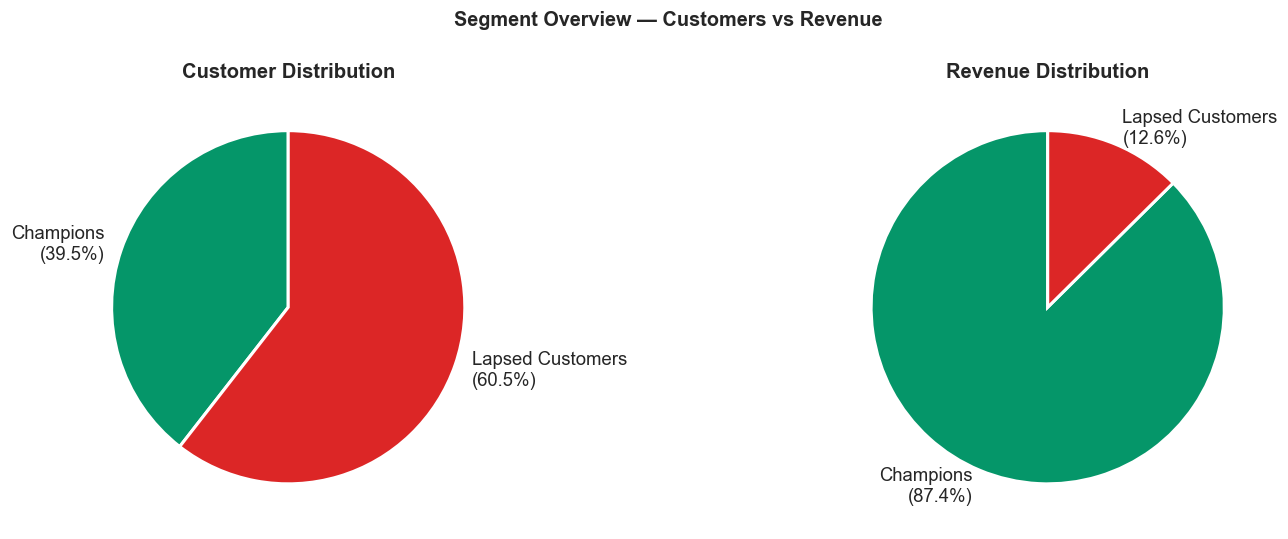

In [3]:
# Full segment summary table
summary = rfm.groupby('Segment').agg(
    Customers  = ('CustomerID', 'count'),
    Recency    = ('Recency',    'mean'),
    Frequency  = ('Frequency',  'mean'),
    Monetary   = ('Monetary',   'mean'),
    TotalRev   = ('Monetary',   'sum'),
).round(2)

summary['Pct_Customers'] = (
    summary['Customers'] / summary['Customers'].sum() * 100
).round(1)
summary['Pct_Revenue'] = (
    summary['TotalRev'] / summary['TotalRev'].sum() * 100
).round(1)

print('=== Segment Summary ===')
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_seg = [SEGMENT_COLORS.get(s, BLUE) for s in summary.index]

axes[0].pie(
    summary['Customers'],
    labels=[f'{s}\n({p:.1f}%)' for s, p in
            zip(summary.index, summary['Pct_Customers'])],
    colors=colors_seg,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    startangle=90
)
axes[0].set_title('Customer Distribution', fontweight='bold')

axes[1].pie(
    summary['TotalRev'],
    labels=[f'{s}\n({p:.1f}%)' for s, p in
            zip(summary.index, summary['Pct_Revenue'])],
    colors=colors_seg,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    startangle=90
)
axes[1].set_title('Revenue Distribution', fontweight='bold')

plt.suptitle('Segment Overview — Customers vs Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Snake Plot

A snake plot shows normalised RFM values per segment on one chart.
It makes it easy to see how segments differ across all three dimensions simultaneously.

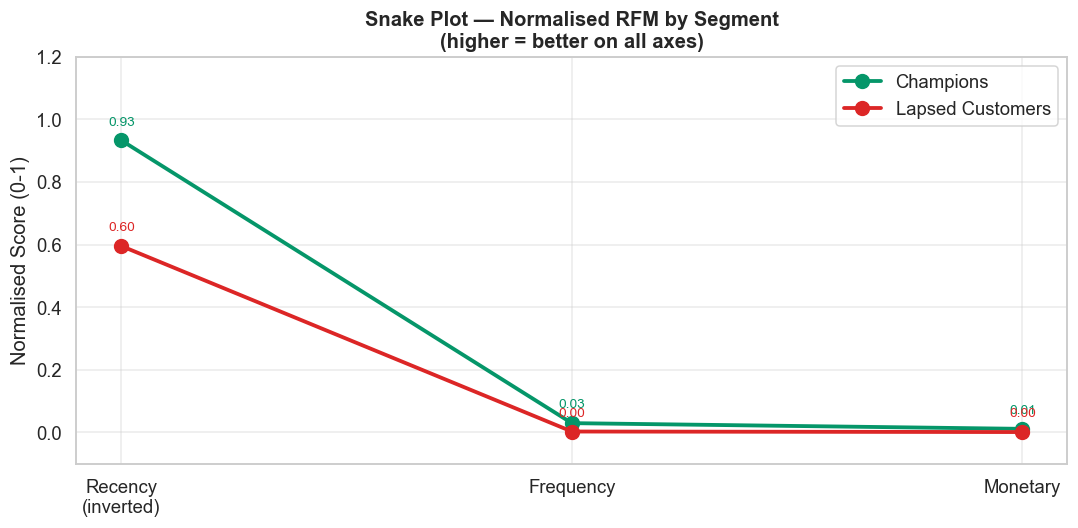

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Normalise RFM to 0-1 for snake plot
scaler_mm = MinMaxScaler()
rfm_norm  = rfm.copy()
rfm_norm[['Recency','Frequency','Monetary']] = scaler_mm.fit_transform(
    rfm[['Recency','Frequency','Monetary']]
)

# For Recency, invert so higher = better (more recent)
rfm_norm['Recency'] = 1 - rfm_norm['Recency']

snake_data = rfm_norm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

plt.figure(figsize=(10, 5))
for segment in snake_data.index:
    color = SEGMENT_COLORS.get(segment, BLUE)
    plt.plot(
        ['Recency\n(inverted)', 'Frequency', 'Monetary'],
        snake_data.loc[segment],
        marker='o', linewidth=2.5, markersize=9,
        label=segment, color=color
    )
    # Label values
    for i, val in enumerate(snake_data.loc[segment]):
        plt.annotate(f'{val:.2f}',
                     xy=(i, val),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color=color)

plt.title('Snake Plot — Normalised RFM by Segment\n(higher = better on all axes)',
          fontweight='bold')
plt.ylabel('Normalised Score (0-1)')
plt.ylim(-0.1, 1.2)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## 4. Revenue Concentration Analysis

Champions represent 39.5% of customers
Champions generate  87.4% of revenue
Revenue multiplier: 2.2x their customer share


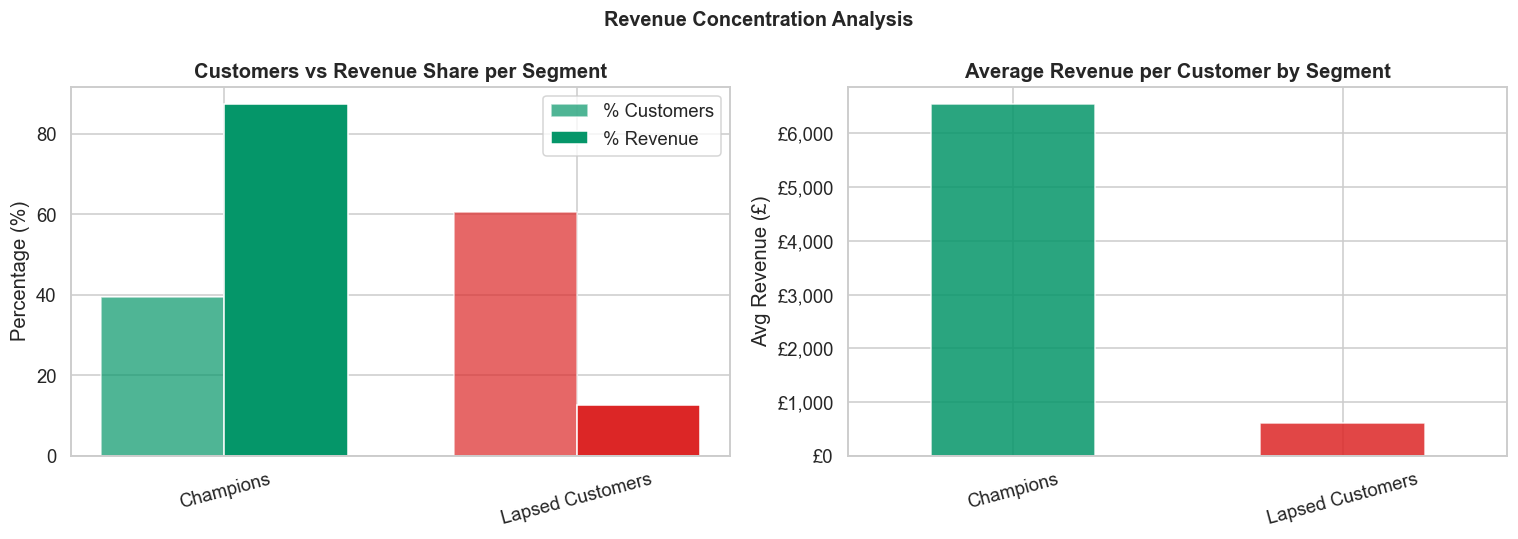

In [5]:
# How much revenue do Champions generate vs their customer share?
champ_customers = summary.loc['Champions', 'Pct_Customers']
champ_revenue   = summary.loc['Champions', 'Pct_Revenue']

print(f'Champions represent {champ_customers:.1f}% of customers')
print(f'Champions generate  {champ_revenue:.1f}% of revenue')
print(f'Revenue multiplier: {champ_revenue/champ_customers:.1f}x their customer share')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer vs Revenue share comparison
x = np.arange(len(summary))
width = 0.35
axes[0].bar(x - width/2, summary['Pct_Customers'],
            width, label='% Customers',
            color=[SEGMENT_COLORS.get(s, BLUE) for s in summary.index],
            alpha=0.7)
axes[0].bar(x + width/2, summary['Pct_Revenue'],
            width, label='% Revenue',
            color=[SEGMENT_COLORS.get(s, BLUE) for s in summary.index],
            alpha=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary.index, rotation=15)
axes[0].set_title('Customers vs Revenue Share per Segment', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend()

# Average revenue per customer
summary['AvgRevPerCustomer'] = summary['TotalRev'] / summary['Customers']
colors_avg = [SEGMENT_COLORS.get(s, BLUE) for s in summary.index]
summary['AvgRevPerCustomer'].plot(kind='bar', ax=axes[1],
                                   color=colors_avg, alpha=0.85)
axes[1].set_title('Average Revenue per Customer by Segment', fontweight='bold')
axes[1].set_ylabel('Avg Revenue (£)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('Revenue Concentration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Purchase Behaviour by Segment

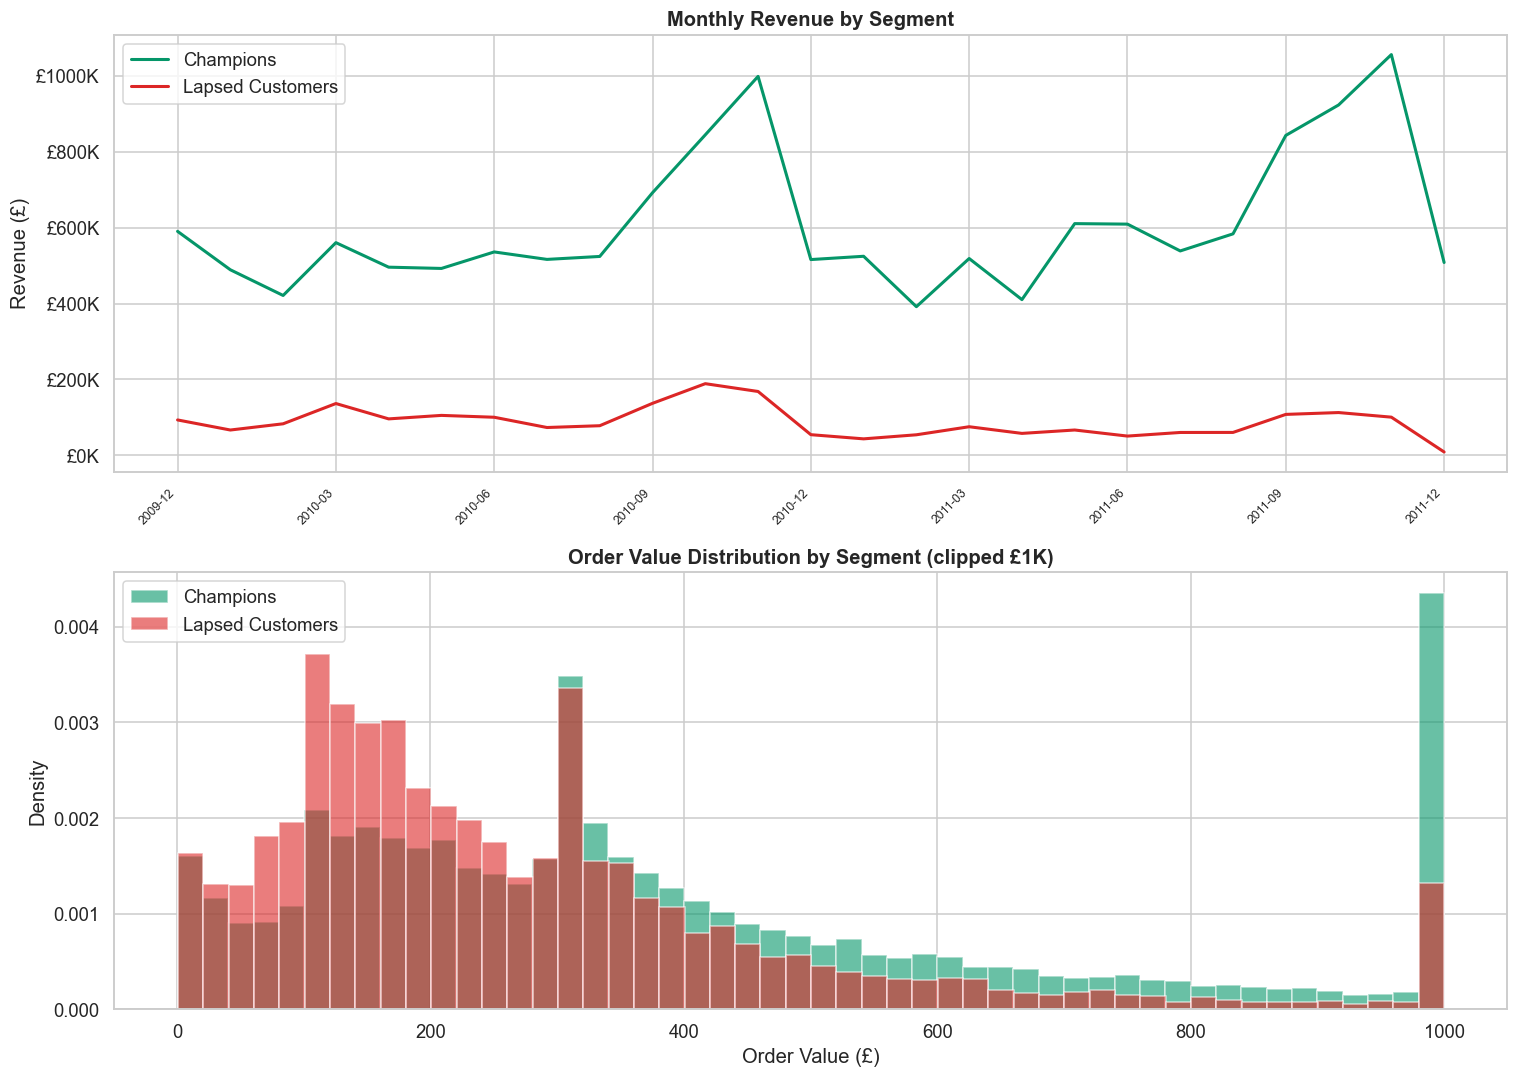

In [6]:
# Monthly purchase patterns by segment
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_seg = df.groupby(['YearMonth','Segment'])['Revenue'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for segment in monthly_seg.columns:
    color = SEGMENT_COLORS.get(segment, BLUE)
    axes[0].plot(range(len(monthly_seg)),
                 monthly_seg[segment],
                 label=segment, color=color, linewidth=2)

axes[0].set_title('Monthly Revenue by Segment', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].set_xticks(range(0, len(monthly_seg), 3))
axes[0].set_xticklabels(
    [monthly_seg.index[i] for i in range(0, len(monthly_seg), 3)],
    rotation=45, ha='right', fontsize=8
)
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].legend()

# Order value distribution by segment
order_val = df.groupby(['Invoice','Segment'])['Revenue'].sum().reset_index()
for segment in order_val['Segment'].dropna().unique():
    color = SEGMENT_COLORS.get(segment, BLUE)
    subset = order_val[order_val['Segment']==segment]['Revenue'].clip(0, 1000)
    axes[1].hist(subset, bins=50, alpha=0.6, label=segment,
                 color=color, density=True)

axes[1].set_title('Order Value Distribution by Segment (clipped £1K)', fontweight='bold')
axes[1].set_xlabel('Order Value (£)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Geographic Distribution by Segment

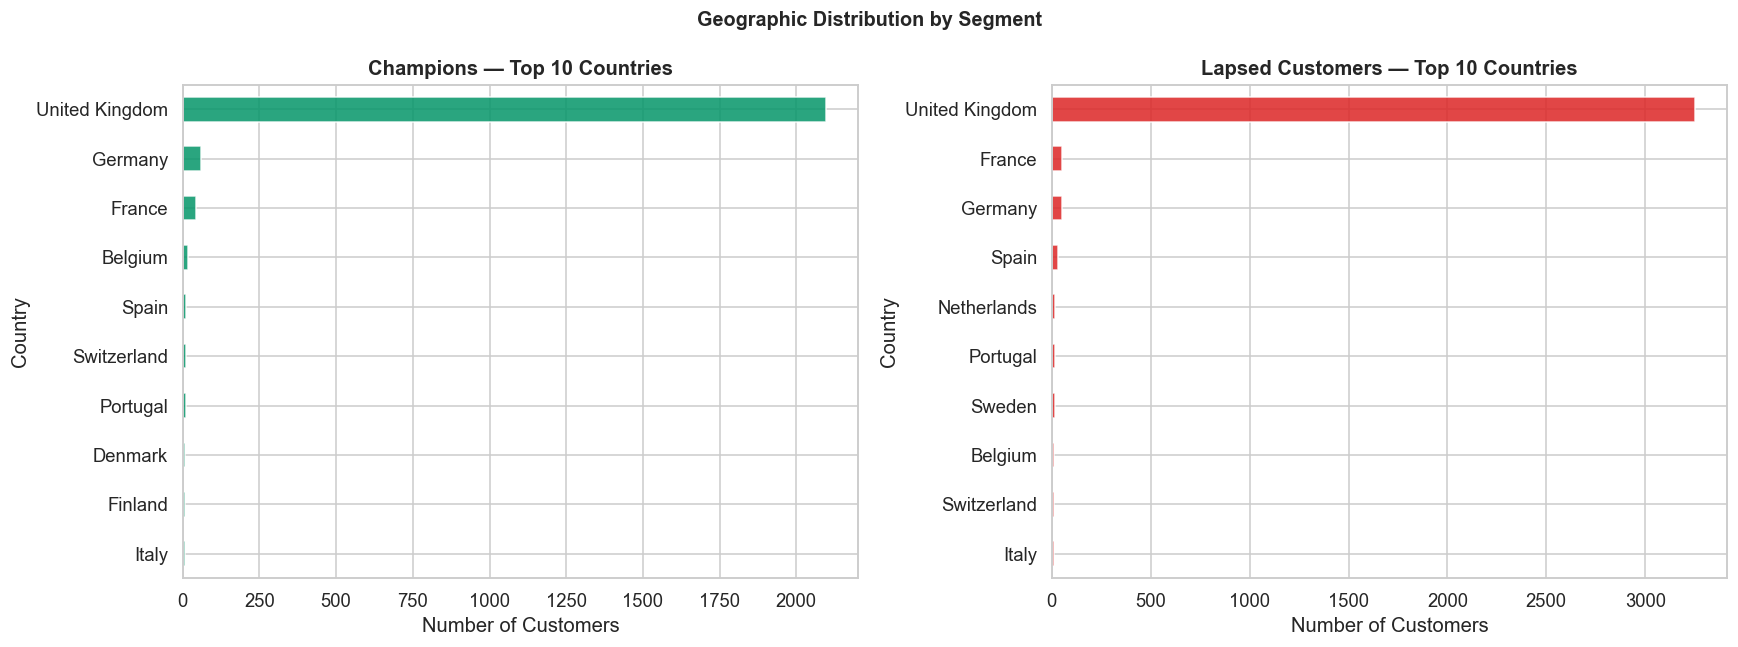

In [7]:
# Top countries per segment
country_seg = df.groupby(['Country','Segment'])['CustomerID'].nunique().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, segment in enumerate(rfm['Segment'].unique()):
    if segment not in country_seg.columns:
        continue
    color = SEGMENT_COLORS.get(segment, BLUE)
    top10 = country_seg[segment].sort_values(ascending=False).head(10)
    top10.plot(kind='barh', ax=axes[i], color=color, alpha=0.85)
    axes[i].set_title(f'{segment} — Top 10 Countries', fontweight='bold')
    axes[i].set_xlabel('Number of Customers')
    axes[i].invert_yaxis()

plt.suptitle('Geographic Distribution by Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Business Recommendations

In [8]:
champ_rev_pct  = summary.loc['Champions', 'Pct_Revenue']
champ_cust_pct = summary.loc['Champions', 'Pct_Customers']
champ_avg_rev  = summary.loc['Champions', 'AvgRevPerCustomer']
lapsed_count   = summary.loc['Lapsed Customers', 'Customers']
lapsed_avg_rev = summary.loc['Lapsed Customers', 'AvgRevPerCustomer']

print(f"""
=================================================================
              BUSINESS RECOMMENDATIONS
=================================================================

SEGMENT 1 — CHAMPIONS ({champ_cust_pct:.1f}% of customers, {champ_rev_pct:.1f}% of revenue)
  Average Revenue: £{champ_avg_rev:,.2f} per customer

  Strategy: RETAIN AND REWARD
  - Enrol in VIP loyalty programme with exclusive benefits
  - Offer early access to new products and seasonal collections
  - Send personalised thank-you communications
  - Upsell premium product lines — they have high spend capacity
  - Request reviews and referrals — they are your brand advocates
  - Set up subscription/auto-replenishment for repeat purchases

  Risk: Losing one Champion costs ~£{champ_avg_rev:,.0f} in revenue.
  Priority: HIGHEST — protect this segment at all costs.

-----------------------------------------------------------------

SEGMENT 2 — LAPSED CUSTOMERS ({100-champ_cust_pct:.1f}% of customers)
  Average Revenue: £{lapsed_avg_rev:,.2f} per customer
  Total customers to reactivate: {lapsed_count:,}

  Strategy: REACTIVATE
  - Send win-back email campaign with time-limited discount
  - Survey why they stopped purchasing
  - Showcase new products they have not seen
  - Offer free shipping on next order to reduce friction
  - Segment further by recency — 300-400 days vs 100-200 days
    need different urgency levels in messaging

  Opportunity: Converting just 10% of lapsed customers to
  Champions would add £{lapsed_count * 0.10 * (champ_avg_rev - lapsed_avg_rev):,.0f}
  in incremental annual revenue.

=================================================================
""")


              BUSINESS RECOMMENDATIONS

SEGMENT 1 — CHAMPIONS (39.5% of customers, 87.4% of revenue)
  Average Revenue: £6,546.97 per customer

  Strategy: RETAIN AND REWARD
  - Enrol in VIP loyalty programme with exclusive benefits
  - Offer early access to new products and seasonal collections
  - Send personalised thank-you communications
  - Upsell premium product lines — they have high spend capacity
  - Request reviews and referrals — they are your brand advocates
  - Set up subscription/auto-replenishment for repeat purchases

  Risk: Losing one Champion costs ~£6,547 in revenue.
  Priority: HIGHEST — protect this segment at all costs.

-----------------------------------------------------------------

SEGMENT 2 — LAPSED CUSTOMERS (60.5% of customers)
  Average Revenue: £614.34 per customer
  Total customers to reactivate: 3,558

  Strategy: REACTIVATE
  - Send win-back email campaign with time-limited discount
  - Survey why they stopped purchasing
  - Showcase new products th

---
## 8. Key Insights

In [ ]:
print(f"""
=================================================================
                    KEY INSIGHTS
=================================================================

  1. CLEAR TWO-SEGMENT STRUCTURE
     The dataset naturally separates into two distinct groups.
     The silhouette score of {stats['silhouette_score']} confirms
     well-separated clusters.

  2. CHAMPIONS DRIVE DISPROPORTIONATE VALUE
     {champ_cust_pct:.1f}% of customers generate {champ_rev_pct:.1f}% of revenue.
     Each Champion is worth {champ_avg_rev/lapsed_avg_rev:.1f}x a Lapsed Customer.
     Retaining Champions is the highest ROI activity.

  3. LARGE REACTIVATION OPPORTUNITY
     {lapsed_count:,} lapsed customers with avg £{lapsed_avg_rev:.2f} spend.
     Even a small reactivation rate creates significant revenue uplift.

  4. RFM DIFFERENCES ARE STARK
     Champions buy 6x more often and spend 10x more than Lapsed.
     Recency gap: 51 days vs 300 days — almost a year of inactivity.

  5. MARKETING BUDGET ALLOCATION
     Recommended split:
     - 60% on Champions retention (highest LTV, lowest churn risk)
     - 40% on Lapsed reactivation (large pool, proven purchase intent)

  NEXT STEP -> Build Streamlit dashboard
=================================================================
""")